In [1]:
%matplotlib ipympl
import geopandas as gpd
import leafmap as lm
import pandas as pd
import re
import numpy as np
import fiona
import matplotlib.pyplot as plt

In [2]:
def parse_num_piani(value):
    """
    Converte il numero di piani espresso in formato testo ('6+1', '3 + 2', ecc.)
    in un valore numerico (somma degli addendi). Restituisce NaN se non interpretabile.
    """
    if pd.isna(value):
        return np.nan

    if isinstance(value, (int, float)):
        return value

    s = str(value).strip()

    # Rimuovi spazi e caratteri strani
    s = re.sub(r'\s+', '', s)

    # Se contiene '+', somma i numeri
    if '+' in s:
        try:
            nums = [float(n) for n in s.split('+') if n.strip().isdigit()]
            return sum(nums)
        except Exception:
            pass

    # Se contiene '-', prendi il valore massimo (es. '7-8' → 8)
    if '-' in s:
        try:
            nums = [float(n) for n in s.split('-') if n.strip().isdigit()]
            return max(nums)
        except Exception:
            pass

    # Se è un numero puro
    try:
        return float(s)
    except ValueError:
        return np.nan

import pandas as pd

CLASSES = [
    (None, 1918),   # prima del 1918 (incluso)
    (1919, 1945),
    (1946, 1960),
    (1961, 1970),
    (1971, 1980),
    (1981, 1990),
    (1991, 2000),
    (2001, 2005),
    (2006, 2012),
    (2013, None),   # dopo il 2012
]

def anno_to_classe(year):
    # gestisce None, NaN, stringhe vuote, ecc.
    if year is None or (isinstance(year, float) and pd.isna(year)) or (isinstance(year, str) and not year.strip()):
        return None

    # prova a convertire a int (se arriva come stringa "1997")
    try:
        y = int(year)
    except (TypeError, ValueError):
        return None

    # regole
    if y <= 1918:
        return (None, 1918)
    if y > 2012:
        return (2013, None)

    # cerca nell’elenco
    for start, end in CLASSES:
        if start is not None and end is not None and start <= y <= end:
            return (start, end)

    return None


In [3]:
path = r"C:\Users\Mocci\PycharmProjects\GeneralPurpose\to_building_energy\data\staging\aoi.gpkg"
all_layers = set(fiona.listlayers(path))
all_layers

{'Census Sections',
 'PED Area',
 'PED neighborhoods 200m',
 'ace',
 'ace__dup',
 'addresses',
 'ape_co_clean',
 'ape_co_orphans',
 'ape_de_clean',
 'ape_de_orphans',
 'ape_dg',
 'ape_dg__dup',
 'ape_dtag_clean',
 'ape_dtag_orphans',
 'ape_dter_clean',
 'ape_dter_orphans',
 'ape_dtre_clean',
 'ape_dtre_orphans',
 'ape_im_clean',
 'ape_im_orphans',
 'ape_imde_clean',
 'ape_imde_orphans',
 'ape_vi_clean',
 'ape_vi_orphans',
 'buildings_parts',
 'cit_clean',
 'cit_orphans',
 'ped_neigh_200m'}

In [4]:
blg_parts = gpd.read_file(path, layer='buildings_parts').to_crs('32632')
addrs = gpd.read_file(path, layer='addresses').to_crs('32632')

#APE
ape = gpd.read_file(path, layer='ape_dg').to_crs('32632')
ape_de = gpd.read_file(path, layer='ape_de_clean')
ape_dtag = gpd.read_file(path, layer='ape_dtag_clean')
ape_dter = gpd.read_file(path, layer='ape_dter_clean')
ape_dtre = gpd.read_file(path, layer='ape_dtre_clean')

# 1:N
ape_co = gpd.read_file(path, layer='ape_co_clean')
ape_im = gpd.read_file(path, layer='ape_im_clean')
ape_imde = gpd.read_file(path, layer='ape_imde_clean')
#CIT 1:N
cit = gpd.read_file(path, layer='cit_clean') # Non usato al momento

# ACE
ace = gpd.read_file(path, layer='ace').to_crs('32632')



# Preprocessing EPC

## Preprocessing APE

In [5]:
ape_key = 'id_certificato'
apec = ape.merge(ape_de, left_on=ape_key, right_on=ape_key, how='left')
apec = apec.merge(ape_dtag, left_on=ape_key, right_on=ape_key, how='left')
apec = apec.merge(ape_dter.add_suffix('_ref'), left_on=ape_key, right_on=ape_key+'_ref', how='left')
apec = apec.merge(ape_dtre, left_on=ape_key, right_on=ape_key, how='left')

ape_cols = {
        ape_key: ape_key,
        'oggetto_ape':'subject',
        'nr_um':'n_apts',
        'motivazione_rilascio':'why',
        'destinazione_uso':'blg_use', 
        'sup_disperdente':'heat_loss_area', # heat loss area (tetti, solai, muri, etc) con l'esterno e con aree non controllate
        'sup_riscaldata':'heating_floor_area', # heating_floor_area
        'sup_raffrescata':'cooling_floor_area', #cooling_floor_area
        'vol_lordo_riscaldato':'heating_gross_volume', # heating gross volume
        'vol_lordo_raffrescato':'cooling_gross_volume', # cooling gross volume
        'anno_costruzione':'construction_year', # year of construction
        'anno_ult_rist':'last_renovation_year', # last_renovation
        'classe_energetica':'energy_class', # energy class
        'eph':'eph', # L'EPH (Indice di Prestazione Termica utile per il riscaldamento) misura il fabbisogno di energia dell'involucro edilizio per la climatizzazione invernale. Espresso in (kWh/m^{2}
        'yie':'yie', #  Trasmittanza termica periodica YIE (W/m²K)
        'asol_asup':'asol_asup', #Area solare equivalente estiva per unità di superficie utile
        'epgl_nren_globale':'epgl_nren_gl', # L'EPgl,nren (Indice di Prestazione Energetica Globale non rinnovabile) nell'APE misura l'energia da fonti non rinnovabili consumata annualmente per metro quadro (\(kWh/m^{2}\) anno) per riscaldamento, raffrescamento, acqua calda, ventilazione e illuminazione
        'epgl_ren_globale':'epgl_ren_gl', # # L'EPgl,nren (Indice di Prestazione Energetica Globale rinnovabile) nell'APE misura l'energia da fonti rinnovabili consumata annualmente per metro quadro (\(kWh/m^{2}\) anno) per riscaldamento, raffrescamento, acqua calda, ventilazione e illuminazione
        'emissioni_co2':'emissions',
        'rapporto_sv':'sv',
        'sup_disp_tot_opaca':'tot_opaque_area',
        'trasmittanza_med_sup_opache':'avg_trasm_opaque',
        'sup_disp_tot_trasp':'tot_trasp_area',
        'trasmittanza_med_sup_trasp':'avg_trasm_trasp',
        'portata_ventilazione_tot':'m3_h',
        'geometry':'geometry'
}

apef = apec[ape_cols.keys()].rename(columns=ape_cols)

In [6]:
# sanitize
apef.last_renovation_year = pd.to_numeric(apef.last_renovation_year,errors='coerce')
apef.construction_year = pd.to_numeric(apef.construction_year,errors='coerce')
apef['construction_epoch'] = apef.construction_year.apply(anno_to_classe)
apef.n_apts = pd.to_numeric(apef.n_apts,errors='coerce')

# filtering
# only Unità Immobiliare
apef = apef.loc[apef.subject == "Unita' immobiliare"]
# classification renovated or not
filt = (apef['why'].isin(['Riqualificazione energetica',
       'Ristrutturazione importante','Altro'])) | (apef['construction_year']<apef['last_renovation_year'])
apef["renov"] = filt

In [7]:
# merging 1:N 

# ape_co
ape_co = ape_co.drop(columns=["altro_descr_comb","id_qta_consumi"])
ape_co_agg = ape_co.groupby(ape_key).apply(lambda g: g.drop(columns=[ape_key]).to_dict("records")).reset_index(name="cons")

apef = apef.merge(ape_co_agg, left_on=ape_key, right_on=ape_key, how='left')

# ape_im e ape_imde
serv_ener = {
    "<sezioneAcquaCalda>": 3,
    "<sezioneClimaEst>": 2,
    "<sezioneClimaInver>": 1,
    "<sezioneIlluminazione>": 7,
    "<sezioneImpiantiCombinati>": 4,
    "<sezioneProdFontiRinn>": 5,
    "<sezioneTrasporto>": 8,
    "<sezioneVentMecc>": 6,
    "None": 0,
}
ape_im = ape_im.drop(columns=["id_dettaglio_imp"])
ape_im['id_serv_ener'] =  ape_im["serv_ener"].apply(lambda x: serv_ener[x])
ape_im.codice_impianto_cit = pd.to_numeric(ape_im.codice_impianto_cit, errors='coerce')
#ape_im.groupby(ape_key, as_index=False).agg(lambda x: tuple(x))
ape_im['cert_im'] = ape_im.id_certificato + '_' + ape_im.id_serv_ener.astype(str)
ape_im = ape_im.drop_duplicates(subset=['cert_im'])
ape_imde['cert_im'] = ape_imde.id_certificato + '_' + ape_imde.id_serv_ener.astype(str)

ape_im = ape_im.merge(ape_imde.drop(columns=[ape_key,'id_serv_ener']), left_on='cert_im', right_on='cert_im', how='left',validate='one_to_one').drop(columns=['cert_im'])

ape_im_agg = ape_im.groupby(ape_key).apply(lambda g: g.drop(columns=[ape_key]).to_dict("records")).reset_index(name="plants")

apef = apef.merge(ape_im_agg, left_on=ape_key, right_on=ape_key, how='left')

## Preprocessing ACE

In [8]:
import pandas as pd
import re

def classifica_immobile(x):
    if pd.isna(x):
        return None
    
    x = x.lower()

    # 0️⃣ esclusione esplicita plurali appartamenti
    if re.search(r'\bappartament[i]\b', x):
        return 'EDIFICIO'
    
    # 1️⃣ COMMERCIALE
    commerciale = [
        'negoz', 'local', 'commerc', 'uffic', 'stud',
        'laborator', 'magazz', 'bar', 'ristor',
        'pizzer', 'attivit', 'botteg', 'officin',
        'capannon', 'deposit', 'autorimess', 'box',
        'banc', 'credit', 'palestr', 'clinic',
        'centro', 'esposizion'
    ]
    if any(k in x for k in commerciale):
        return 'COMMERCIALE'
    
    # 2️⃣ APPARTAMENTO
    appartamento = [
        'appartamento', 'alloggio', 'abitazione', 'civile abitazione',
        'monolocale', 'mansarda', 'soffitta', 'attico', 'duplex',
        'loft', 'monocamera', 'residenziale', 'unità indipendente',
    ]
    if any(k in x for k in appartamento):
        return 'APPARTAMENTO'
    
    # 3️⃣ EDIFICIO
    edificio = [
        'edific',
        'condomin',
        'palazz',
        'fabbricat',
        'stabil',
        'torr',
        'compless'
    ]
    if any(k in x for k in edificio):
        return 'EDIFICIO'
    
    # fallback
    return 'ALTRO'

In [9]:
ace_key = 'id_certificato'
acec = ace.copy()
ace_cols = {
        ace_key: ace_key,
        'desc_tipo_edificio':'subject',
        'num_appartamenti':'n_apts',
        'sup_disperdente_tot':'heat_loss_area', # heat loss area (tetti, solai, muri, etc) con l'esterno e con aree non controllate
        'anno_costruzione':'construction_year', # year of construction
        'anno_ult_rist':'last_renovation_year', # last_renovation
        'ind_risc_epi':'eph', # L'EPH (Indice di Prestazione Termica utile per il riscaldamento) misura il fabbisogno di energia dell'involucro edilizio per la climatizzazione invernale. Espresso in (kWh/m^{2}
        'ind_glob_eplordo':'epgl_nren_gl', # L'EPgl,nren (Indice di Prestazione Energetica Globale non rinnovabile) nell'APE misura l'energia da fonti non rinnovabili consumata annualmente per metro quadro (\(kWh/m^{2}\) anno) per riscaldamento, raffrescamento, acqua calda, ventilazione e illuminazione
        'fattore_forma':'sv',
        'trasm_opache':'avg_trasm_opaque',
        'trasm_trasp':'avg_trasm_trasp',
        'geometry':'geometry'
}

acef = acec[ace_cols.keys()].rename(columns=ace_cols)

In [10]:
# sanitize 
acef.last_renovation_year = pd.to_numeric(acef.last_renovation_year,errors='coerce')
acef.construction_year = pd.to_numeric(acef.construction_year,errors='coerce')
acef['construction_epoch'] = acef.construction_year.apply(anno_to_classe)

acef.n_apts = pd.to_numeric(acef.n_apts,errors='coerce')
# filtering
acef['subject'] = acef.subject.apply(classifica_immobile)
acef = acef.loc[acef.subject == 'APPARTAMENTO']

filt = (acef['construction_year']<acef['last_renovation_year'])
acef["renov"] = filt


In [11]:
acef = acef.merge(ape_im_agg, left_on=ace_key, right_on=ace_key, how='left')
acef = acef.merge(ape_co_agg, left_on=ace_key, right_on=ace_key, how='left')

## Merging

In [12]:
epc = pd.concat([apef,acef])
epc.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 12282 entries, 0 to 4828
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   id_certificato        12282 non-null  object  
 1   subject               12282 non-null  object  
 2   n_apts                9799 non-null   float64 
 3   why                   7453 non-null   object  
 4   blg_use               7453 non-null   object  
 5   heat_loss_area        12282 non-null  float64 
 6   heating_floor_area    7399 non-null   float64 
 7   cooling_floor_area    6848 non-null   float64 
 8   heating_gross_volume  7453 non-null   float64 
 9   cooling_gross_volume  6839 non-null   float64 
 10  construction_year     12282 non-null  float64 
 11  last_renovation_year  1967 non-null   float64 
 12  energy_class          7453 non-null   object  
 13  eph                   12282 non-null  float64 
 14  yie                   7453 non-null   float64 
 15  

In [13]:
epc.construction_year

0       1952.0
1       2005.0
2       2005.0
3       1990.0
4       1989.0
         ...  
4824    1911.0
4825    1911.0
4826    1952.0
4827    1911.0
4828    1911.0
Name: construction_year, Length: 12282, dtype: float64

# Identificazione Building Blocks

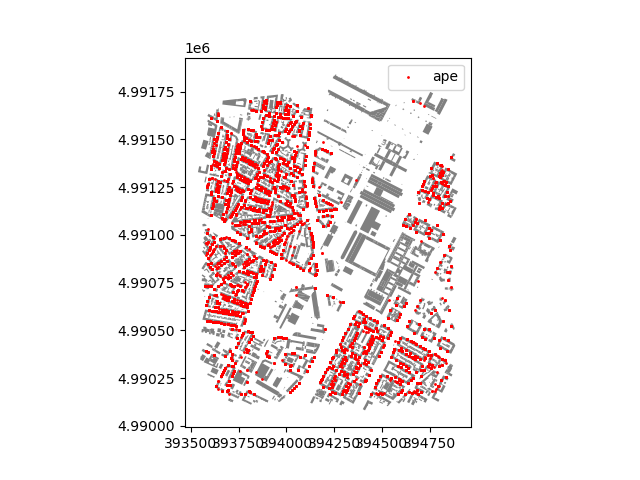

In [14]:
fig, ax = plt.subplots()
blg_parts.plot(ax=ax,color='grey',label='blg_parts')
epc.plot(ax=ax,markersize=1,color='red',label='ape')
plt.legend()
plt.show()

In [15]:
import re
import pandas as pd

def intervallo_to_tuple(val):
    if pd.isna(val):
        return None

    val = val.strip().lower()

    if val == "non conosciuto":
        return None

    # caso "1918 (al ..)" → prima del 1918
    if val.startswith("1918"):
        return (None, 1918)

    # intervallo tipo "1961 - 1970"
    m = re.match(r"(\d{4})\s*-\s*(\d{4})", val)
    if m:
        start, end = int(m.group(1)), int(m.group(2))
        if start > 2012 or end > 2012:
            return (2013, None)
        return (start, end)

    # anno singolo
    m = re.match(r"(\d{4})", val)
    if m:
        year = int(m.group(1))
        if year > 2012:
            return (2013, None)
        return (year, year)

    return None


In [16]:
# processing buildings footprint
blg_parts = blg_parts[blg_parts['gruppo']=='EDIFICI PRINCIPALI']
blg_parts = blg_parts.fillna('NULL')
blg_parts['numero_piani'] =  blg_parts['numero_piani'].apply(parse_num_piani)
blg_parts['area'] = blg_parts.geometry.area
blg_parts['part_id'] = ['pt_' + str(i+1) for i in range(len(blg_parts))]

print((pd.to_numeric(blg_parts.altezza_edificio,errors='coerce')/blg_parts.numero_piani).describe())
mode_storey_height = (pd.to_numeric(blg_parts.altezza_edificio,errors='coerce')/blg_parts.numero_piani).mode()
print(f'mode :{mode_storey_height}')

cols = ['epoca_costruzione'] #['categoria_uso','epoca_costruzione','numero_piani']
# dissolve equals
dissolved = blg_parts.dissolve(by=cols,as_index=False)
dissolved = dissolved.explode(index_parts=False).reset_index(drop=True)
dissolved['block_id'] = ['bb_' + str(i+1) for i in range(len(dissolved))]
dissolved = dissolved[['block_id']+cols+['geometry']]


dissolved["construction_epoch"] = dissolved["epoca_costruzione"].apply(intervallo_to_tuple)

joined = gpd.sjoin(blg_parts, dissolved[['block_id','geometry']], predicate='within', how='left')

agg = joined.groupby('block_id').agg(
        storeys_mean = ('numero_piani','mean'),
        storeys_list = ('numero_piani',lambda x: list(x)),
        blg_uses_list = ('categoria_uso', lambda x: set(x)),
        area_mean = ('area','mean'),
        area_sum = ('area','sum'),
        area_std  = ('area','std'),
).reset_index()

dissolved = dissolved.merge(agg, left_on='block_id', right_on='block_id', how='left')

nearest_parts = gpd.sjoin_nearest(addrs, dissolved[['block_id','geometry']],how='left', max_distance=100, distance_col='dist')
null_part = nearest_parts.loc[nearest_parts.block_id.isna()]
nearest_parts = nearest_parts.drop(null_part.index) # if not associated with an address, drop

agg = nearest_parts.groupby('block_id').agg(
        n_addresses = ('id','count'),
).reset_index()

# block_id non associati a nessun indirizzo e quindi a nessun ape li scarto
not_joined = dissolved.loc[~dissolved.block_id.isin(nearest_parts.block_id)]
dissolved = dissolved.drop(not_joined.index)

dissolved = dissolved.merge(agg, left_on='block_id', right_on='block_id', how='left')

dissolved['n_apts'] = dissolved['storeys_mean']*dissolved['n_addresses']*2 # HP

blg_blocks = dissolved.copy()

count    1979.000000
mean        4.016979
std         0.987708
min         1.120000
25%         3.550000
50%         3.754000
75%         4.148333
max        12.145000
dtype: float64
mode :0    3.66
dtype: float64


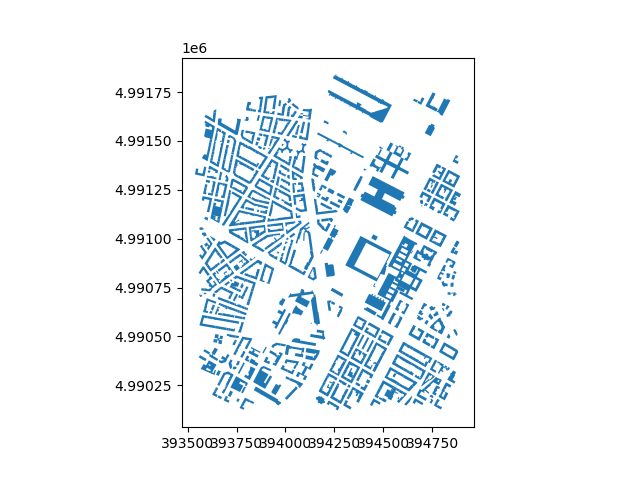

In [17]:
fig, ax = plt.subplots()
dissolved.plot(ax=ax)
plt.show()

In [18]:
blg_blocks

,block_id,epoca_costruzione,geometry,construction_epoch,storeys_mean,storeys_list,blg_uses_list,area_mean,area_sum,area_std,n_addresses,n_apts
0,bb_2,1918 (al ..),"POLYGON ((394393.12 4990388.677, 394394.403 49...","(None, 1918)",3.000000,[3.0],{residenziale},119.279900,119.279900,NaN,1,6.000000
1,bb_3,1918 (al ..),"POLYGON ((394554.235 4990380.517, 394555.206 4...","(None, 1918)",6.666667,"[7.0, 8.0, 5.0]",{residenziale},161.279579,483.838736,72.604219,6,80.000000
2,bb_4,1918 (al ..),"POLYGON ((394279.051 4990387.131, 394279.449 4...","(None, 1918)",5.000000,[5.0],{residenziale},302.026269,302.026269,NaN,4,40.000000
3,bb_5,1918 (al ..),"POLYGON ((394602.097 4990423.545, 394595.629 4...","(None, 1918)",6.333333,"[7.0, 6.0, 6.0]",{residenziale},332.760949,998.282846,213.462792,4,50.666667
4,bb_6,1918 (al ..),"POLYGON ((393658.33 4990644.336, 393658.64 499...","(None, 1918)",2.000000,[2.0],{residenziale},95.702989,95.702989,NaN,1,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
758,bb_880,non conosciuto,"POLYGON ((394721.067 4991181.74, 394723.995 49...",None,2.000000,"[1.0, 3.0]",{non conosciuto},98.230640,196.461280,131.110384,2,8.000000
759,bb_881,non conosciuto,"POLYGON ((394705.341 4991184.893, 394703.714 4...",None,3.000000,[3.0],{amministrativo},286.202313,286.202313,NaN,2,12.000000
760,bb_883,non conosciuto,"POLYGON ((394722.386 4991244.481, 394725.076 4...",None,4.000000,[4.0],{amministrativo},240.674572,240.674572,NaN,2,16.000000
761,bb_887,non conosciuto,"POLYGON ((394779.827 4991654.008, 394785.458 4...",None,6.333333,"[3.0, 1.0, 15.0]",{amministrativo},899.735835,2699.207505,784.152944,4,50.666667


# Linking EPC

In [19]:
# apc
nearest_epc = gpd.sjoin_nearest(epc[['id_certificato','geometry']],blg_blocks[['block_id','geometry']],
                                        how='left', max_distance=10, distance_col='dist')
nearest_epc = nearest_epc.groupby('block_id')['id_certificato'].agg(list).rename('epc_list').reset_index()
nearest_epc['tot_epc'] = nearest_epc['epc_list'].apply(lambda x: len(x))
blg_blocks = blg_blocks.merge(nearest_epc, left_on='block_id', right_on='block_id', how='left')
blg_blocks = blg_blocks.reset_index(drop=True)
# apartment correction based on epc
blg_blocks['n_apts'] = np.where(blg_blocks.tot_epc>blg_blocks.n_apts,blg_blocks.tot_epc,blg_blocks.n_apts).astype(int) # correction

In [20]:
blg_blocks

,block_id,epoca_costruzione,geometry,construction_epoch,storeys_mean,storeys_list,blg_uses_list,area_mean,area_sum,area_std,n_addresses,n_apts,epc_list,tot_epc
0,bb_2,1918 (al ..),"POLYGON ((394393.12 4990388.677, 394394.403 49...","(None, 1918)",3.000000,[3.0],{residenziale},119.279900,119.279900,NaN,1,6,"[363838323032303030303436383832, 3138313230313...",2.0
1,bb_3,1918 (al ..),"POLYGON ((394554.235 4990380.517, 394555.206 4...","(None, 1918)",6.666667,"[7.0, 8.0, 5.0]",{residenziale},161.279579,483.838736,72.604219,6,80,"[373033323031373030343737303331, 3130383230323...",32.0
2,bb_4,1918 (al ..),"POLYGON ((394279.051 4990387.131, 394279.449 4...","(None, 1918)",5.000000,[5.0],{residenziale},302.026269,302.026269,NaN,4,40,"[313831323031373030313231383135, 3638383230323...",9.0
3,bb_5,1918 (al ..),"POLYGON ((394602.097 4990423.545, 394595.629 4...","(None, 1918)",6.333333,"[7.0, 6.0, 6.0]",{residenziale},332.760949,998.282846,213.462792,4,50,"[31323132303232303030323132313034, 31333132303...",33.0
4,bb_6,1918 (al ..),"POLYGON ((393658.33 4990644.336, 393658.64 499...","(None, 1918)",2.000000,[2.0],{residenziale},95.702989,95.702989,NaN,1,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,bb_880,non conosciuto,"POLYGON ((394721.067 4991181.74, 394723.995 49...",None,2.000000,"[1.0, 3.0]",{non conosciuto},98.230640,196.461280,131.110384,2,8,NaN,NaN
759,bb_881,non conosciuto,"POLYGON ((394705.341 4991184.893, 394703.714 4...",None,3.000000,[3.0],{amministrativo},286.202313,286.202313,NaN,2,12,NaN,NaN
760,bb_883,non conosciuto,"POLYGON ((394722.386 4991244.481, 394725.076 4...",None,4.000000,[4.0],{amministrativo},240.674572,240.674572,NaN,2,16,NaN,NaN
761,bb_887,non conosciuto,"POLYGON ((394779.827 4991654.008, 394785.458 4...",None,6.333333,"[3.0, 1.0, 15.0]",{amministrativo},899.735835,2699.207505,784.152944,4,50,NaN,NaN


In [21]:
# each epc associated to the block_id and id for block_id+renov
block_epcrr = blg_blocks[['block_id', 'epc_list']].explode('epc_list').rename(columns={'epc_list':'id_certificato'})
epcrr = epc.merge(block_epcrr, left_on='id_certificato', right_on='id_certificato', how='left')
epcrr['id'] = epcrr["block_id"] +'_'+ epcrr["renov"].astype(str)

In [22]:
block_epcrr

,block_id,id_certificato
0,bb_2,363838323032303030303436383832
0,bb_2,313831323031333030343031383135
1,bb_3,373033323031373030343737303331
1,bb_3,31303832303231303030313130383734
1,bb_3,373435323032343030303137343535
...,...,...
758,bb_880,NaN
759,bb_881,NaN
760,bb_883,NaN
761,bb_887,NaN


In [23]:
epcrr

,id_certificato,subject,n_apts,why,blg_use,heat_loss_area,heating_floor_area,cooling_floor_area,heating_gross_volume,cooling_gross_volume,...,tot_trasp_area,avg_trasm_trasp,m3_h,geometry,construction_epoch,renov,cons,plants,block_id,id
0,31343532303235303031333134353530,Unita' immobiliare,18.0,Locazione,E1(1),37.07,35.03,35.03,128.55,128.55,...,9.33,3.1315,0.000,POINT (393701.015 4990164.686),"(1946, 1960)",False,NaN,NaN,bb_418,bb_418_False
1,373237323031363030303937323735,Unita' immobiliare,12.0,Passaggio di proprieta',E1(1),85.09,80.23,0.00,279.04,0.00,...,9.12,2.7000,0.000,POINT (393832.572 4990167.855),"(2001, 2005)",False,"[{'quantita': 403.0, 'tipo_combustibile': 'Gas...","[{'anno_install': 2005.0, 'codice_impianto_cit...",bb_599,bb_599_False
2,31343132303234303237343134313736,Unita' immobiliare,12.0,Passaggio di proprieta',E1(1),63.72,76.90,0.00,256.35,0.00,...,15.26,1.5359,103.815,POINT (393832.572 4990167.855),"(2001, 2005)",False,"[{'quantita': 399.0, 'tipo_combustibile': 'Gas...","[{'anno_install': 2023.0, 'codice_impianto_cit...",bb_599,bb_599_False
3,393838323031373030343539383837,Unita' immobiliare,1.0,Locazione,E1(1),56.42,58.42,0.00,202.50,0.00,...,11.25,2.1581,78.870,POINT (393704.95 4990213.424),"(1981, 1990)",False,"[{'quantita': 139.0, 'tipo_combustibile': 'Ene...","[{'anno_install': 2002.0, 'codice_impianto_cit...",bb_586,bb_586_False
4,31313632303230303033333131363331,Unita' immobiliare,23.0,Passaggio di proprieta',E1(1),166.01,121.33,0.00,423.07,0.00,...,26.84,2.2478,163.800,POINT (393704.95 4990213.424),"(1981, 1990)",False,"[{'quantita': 288.0, 'tipo_combustibile': 'Ene...","[{'anno_install': 2011.0, 'codice_impianto_cit...",bb_586,bb_586_False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12277,333537323031323031363633353736,APPARTAMENTO,NaN,NaN,NaN,71.00,NaN,NaN,NaN,NaN,...,NaN,4.9000,NaN,POINT (394019.442 4991676.93),"(None, 1918)",False,NaN,NaN,bb_162,bb_162_False
12278,343033323031333030313034303338,APPARTAMENTO,NaN,NaN,NaN,42.40,NaN,NaN,NaN,NaN,...,NaN,3.9000,NaN,POINT (394019.442 4991676.93),"(None, 1918)",False,NaN,NaN,bb_162,bb_162_False
12279,333837323031323031323933383739,APPARTAMENTO,NaN,NaN,NaN,104.00,NaN,NaN,NaN,NaN,...,NaN,2.8000,NaN,POINT (394019.442 4991676.93),"(1946, 1960)",False,NaN,NaN,bb_162,bb_162_False
12280,333537323031323030363933353736,APPARTAMENTO,NaN,NaN,NaN,37.30,NaN,NaN,NaN,NaN,...,NaN,4.9000,NaN,POINT (394019.442 4991676.93),"(None, 1918)",False,NaN,NaN,bb_162,bb_162_False


## Filling year and epc for empty bb block

In [24]:
# Filling year
epoch_col = "construction_epoch"   # colonna epoca
k = 5                             # numero di vicini
max_dist = 250 # m

gdf2 = blg_blocks.copy()
# from the EPC associated
epc_construction_epoch = epcrr.groupby(['block_id'])['construction_year'].mean().apply(anno_to_classe).rename('epc_construction_epoch') # from the EPC associated
gdf2 = gdf2.merge(epc_construction_epoch, left_on='block_id', right_on='block_id', how='left')

# 1) CRS metrico (importante per distanze)
if gdf2.crs is not None and gdf2.crs.is_geographic:
    # scegli EPSG metrico adatto alla tua zona (esempio: UTM32N)
    gdf2 = gdf2.to_crs(epsg=32632)

# 2) coordinate (centroidi se poligoni)
cent = gdf2.geometry.centroid
coords = np.column_stack([cent.x.values, cent.y.values])

# 3) split noti / mancanti
mask_known = gdf2[epoch_col].notna()
mask_missing = ~mask_known

from sklearn.neighbors import NearestNeighbors
# se non c'è niente da riempire, esci
if mask_missing.sum() > 0 and mask_known.sum() > 0:
    coords_known = coords[mask_known.values]
    coords_missing = coords[mask_missing.values]

    epochs_known_from_epc = gdf2.loc[mask_known, 'epc_construction_epoch'].astype(str).values  # str per sicurezza
    epochs_known_from_bb = gdf2.loc[mask_known, epoch_col].astype(str).values  # str per sicurezza

    k_eff = min(k, len(coords_known))

    nn = NearestNeighbors(n_neighbors=k_eff)
    nn.fit(coords_known)

    dists, idxs = nn.kneighbors(coords_missing)

    def mode_with_tie_break(values, distances=None):
        """
        values: array di classi dei vicini
        distances: array distanze corrispondenti (opzionale)
        tie-break: se pari merito, sceglie la classe con distanza media minore
        """
        s = pd.Series(values)
        counts = s.value_counts()
        top = counts[counts == counts.max()].index.tolist()
        if len(top) == 1 or distances is None:
            return top[0]
        # tie-break: classe con distanza media minore
        best = None
        best_mean_dist = None
        for t in top:
            mean_dist = np.mean(distances[values == t])
            if best is None or mean_dist < best_mean_dist:
                best = t
                best_mean_dist = mean_dist
        return best

    imputed_epochs = []
    for row_dists, row_idxs in zip(dists, idxs):
        neigh_epochs = epochs_known_from_epc[row_idxs]
        if len(neigh_epochs)== 0:
            neigh_epochs = epochs_known_from_bb[row_idxs]

        # opzionale: filtra per distanza massima
        if max_dist is not None:
            valid = row_dists <= max_dist
            if not valid.any():
                imputed_epochs.append(np.nan)
                continue
            neigh_epochs = neigh_epochs[valid]
            row_dists = row_dists[valid]

        imputed_epochs.append(mode_with_tie_break(neigh_epochs, distances=row_dists))

    # 4) scrivi nel gdf
    missing_index = gdf2.index[mask_missing]
    blg_blocks.loc[missing_index, epoch_col] = imputed_epochs


In [25]:
blg_blocks

,block_id,epoca_costruzione,geometry,construction_epoch,storeys_mean,storeys_list,blg_uses_list,area_mean,area_sum,area_std,n_addresses,n_apts,epc_list,tot_epc
0,bb_2,1918 (al ..),"POLYGON ((394393.12 4990388.677, 394394.403 49...","(None, 1918)",3.000000,[3.0],{residenziale},119.279900,119.279900,NaN,1,6,"[363838323032303030303436383832, 3138313230313...",2.0
1,bb_3,1918 (al ..),"POLYGON ((394554.235 4990380.517, 394555.206 4...","(None, 1918)",6.666667,"[7.0, 8.0, 5.0]",{residenziale},161.279579,483.838736,72.604219,6,80,"[373033323031373030343737303331, 3130383230323...",32.0
2,bb_4,1918 (al ..),"POLYGON ((394279.051 4990387.131, 394279.449 4...","(None, 1918)",5.000000,[5.0],{residenziale},302.026269,302.026269,NaN,4,40,"[313831323031373030313231383135, 3638383230323...",9.0
3,bb_5,1918 (al ..),"POLYGON ((394602.097 4990423.545, 394595.629 4...","(None, 1918)",6.333333,"[7.0, 6.0, 6.0]",{residenziale},332.760949,998.282846,213.462792,4,50,"[31323132303232303030323132313034, 31333132303...",33.0
4,bb_6,1918 (al ..),"POLYGON ((393658.33 4990644.336, 393658.64 499...","(None, 1918)",2.000000,[2.0],{residenziale},95.702989,95.702989,NaN,1,4,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,bb_880,non conosciuto,"POLYGON ((394721.067 4991181.74, 394723.995 49...","(None, 1918)",2.000000,"[1.0, 3.0]",{non conosciuto},98.230640,196.461280,131.110384,2,8,NaN,NaN
759,bb_881,non conosciuto,"POLYGON ((394705.341 4991184.893, 394703.714 4...","(None, 1918)",3.000000,[3.0],{amministrativo},286.202313,286.202313,NaN,2,12,NaN,NaN
760,bb_883,non conosciuto,"POLYGON ((394722.386 4991244.481, 394725.076 4...","(None, 1918)",4.000000,[4.0],{amministrativo},240.674572,240.674572,NaN,2,16,NaN,NaN
761,bb_887,non conosciuto,"POLYGON ((394779.827 4991654.008, 394785.458 4...","(1946, 1960)",6.333333,"[3.0, 1.0, 15.0]",{amministrativo},899.735835,2699.207505,784.152944,4,50,NaN,NaN


In [26]:
# Filling epc list most representative
col = "epc_list"   # colonna epoca
k = 5                             # numero di vicini
max_dist = 250 # m

gdf2 = blg_blocks.copy()

# 1) CRS metrico (importante per distanze)
if gdf2.crs is not None and gdf2.crs.is_geographic:
    # scegli EPSG metrico adatto alla tua zona (esempio: UTM32N)
    gdf2 = gdf2.to_crs(epsg=32632)

# 2) coordinate (centroidi se poligoni)
cent = gdf2.geometry.centroid
coords = np.column_stack([cent.x.values, cent.y.values])

# 3) split noti / mancanti
mask_known = gdf2[col].notna()
mask_missing = ~mask_known

missing_index = gdf2.index[mask_missing]

from sklearn.neighbors import NearestNeighbors
# se non c'è niente da riempire, esci
if mask_missing.sum() > 0 and mask_known.sum() > 0:
    coords_known = coords[mask_known.values]
    coords_missing = coords[mask_missing.values]
    
    epc_lists = gdf2.loc[mask_known, ['construction_epoch',col]].values

    k_eff = min(k, len(coords_known))

    nn = NearestNeighbors(n_neighbors=k_eff)
    nn.fit(coords_known)

    dists, idxs = nn.kneighbors(coords_missing)

    def mode_with_tie_break(values, distances=None):
        """
        values: array di classi dei vicini
        distances: array distanze corrispondenti (opzionale)
        tie-break: se pari merito, sceglie la classe con distanza media minore
        """
        s = pd.Series(values)
        counts = s.value_counts()
        top = counts[counts == counts.max()].index.tolist()
        if len(top) == 1 or distances is None:
            return top[0]
        # tie-break: classe con distanza media minore
        best = None
        best_mean_dist = None
        for t in top:
            mean_dist = np.mean(distances[values == t])
            if best is None or mean_dist < best_mean_dist:
                best = t
                best_mean_dist = mean_dist
        return best

    imputed_epochs = []
    i = 0
    for row_dists, row_idxs in zip(dists, idxs):
        neigh_epoch_epcs = epc_lists[row_idxs]

        # opzionale: filtra per distanza massima
        if max_dist is not None:
            valid = row_dists <= max_dist
            if not valid.any():
                imputed_epochs.append(np.nan)
                continue
            neigh_epoch_epcs = neigh_epoch_epcs[valid]
            row_dists = row_dists[valid]
        #filtra epoca giusta
        ref_epoch = gdf2.iloc[missing_index[i]]['construction_epoch']
        neigh_epoch_final = []
        row_dists_final = []
        for i, t in enumerate(neigh_epoch_epcs):
            if str(t[0]) == str(ref_epoch):
                neigh_epoch_final.append(t[1])
                row_dists_final.append(row_dists[i])

        imputed_epochs.append(mode_with_tie_break(neigh_epoch_final, distances=row_dists_final))
        i += 1
    
    # 4) scrivi nel gdf
    blg_blocks.loc[missing_index, col] =  pd.Series(imputed_epochs, index=missing_index, dtype="object")
    blg_blocks['epc_agg']  = False
    blg_blocks.loc[missing_index, 'epc_agg'] = True

In [27]:
blg_blocks

,block_id,epoca_costruzione,geometry,construction_epoch,storeys_mean,storeys_list,blg_uses_list,area_mean,area_sum,area_std,n_addresses,n_apts,epc_list,tot_epc,epc_agg
0,bb_2,1918 (al ..),"POLYGON ((394393.12 4990388.677, 394394.403 49...","(None, 1918)",3.000000,[3.0],{residenziale},119.279900,119.279900,NaN,1,6,"[363838323032303030303436383832, 3138313230313...",2.0,False
1,bb_3,1918 (al ..),"POLYGON ((394554.235 4990380.517, 394555.206 4...","(None, 1918)",6.666667,"[7.0, 8.0, 5.0]",{residenziale},161.279579,483.838736,72.604219,6,80,"[373033323031373030343737303331, 3130383230323...",32.0,False
2,bb_4,1918 (al ..),"POLYGON ((394279.051 4990387.131, 394279.449 4...","(None, 1918)",5.000000,[5.0],{residenziale},302.026269,302.026269,NaN,4,40,"[313831323031373030313231383135, 3638383230323...",9.0,False
3,bb_5,1918 (al ..),"POLYGON ((394602.097 4990423.545, 394595.629 4...","(None, 1918)",6.333333,"[7.0, 6.0, 6.0]",{residenziale},332.760949,998.282846,213.462792,4,50,"[31323132303232303030323132313034, 31333132303...",33.0,False
4,bb_6,1918 (al ..),"POLYGON ((393658.33 4990644.336, 393658.64 499...","(None, 1918)",2.000000,[2.0],{residenziale},95.702989,95.702989,NaN,1,4,"[373435323032343030313537343534, 3437353230313...",NaN,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
758,bb_880,non conosciuto,"POLYGON ((394721.067 4991181.74, 394723.995 49...","(None, 1918)",2.000000,"[1.0, 3.0]",{non conosciuto},98.230640,196.461280,131.110384,2,8,"[343630323031373030303734363039, 3834323230323...",NaN,True
759,bb_881,non conosciuto,"POLYGON ((394705.341 4991184.893, 394703.714 4...","(None, 1918)",3.000000,[3.0],{amministrativo},286.202313,286.202313,NaN,2,12,"[31323232303230303030313132323232, 31373732303...",NaN,True
760,bb_883,non conosciuto,"POLYGON ((394722.386 4991244.481, 394725.076 4...","(None, 1918)",4.000000,[4.0],{amministrativo},240.674572,240.674572,NaN,2,16,"[31323232303230303030313132323232, 31373732303...",NaN,True
761,bb_887,non conosciuto,"POLYGON ((394779.827 4991654.008, 394785.458 4...","(1946, 1960)",6.333333,"[3.0, 1.0, 15.0]",{amministrativo},899.735835,2699.207505,784.152944,4,50,None,NaN,True


In [28]:
# RECALCULATE
# each epc associated to the block_id and id for block_id+renov
block_epc = blg_blocks[['block_id', 'epc_list']].explode('epc_list').rename(columns={'epc_list':'id_certificato'})
epc = epc.merge(block_epc, left_on='id_certificato', right_on='id_certificato', how='left')
epc['id'] = epc["block_id"] +'_'+ epc["renov"].astype(str)

In [29]:
epc

,id_certificato,subject,n_apts,why,blg_use,heat_loss_area,heating_floor_area,cooling_floor_area,heating_gross_volume,cooling_gross_volume,...,tot_trasp_area,avg_trasm_trasp,m3_h,geometry,construction_epoch,renov,cons,plants,block_id,id
0,31343532303235303031333134353530,Unita' immobiliare,18.0,Locazione,E1(1),37.07,35.03,35.03,128.55,128.55,...,9.33,3.1315,0.000,POINT (393701.015 4990164.686),"(1946, 1960)",False,NaN,NaN,bb_418,bb_418_False
1,373237323031363030303937323735,Unita' immobiliare,12.0,Passaggio di proprieta',E1(1),85.09,80.23,0.00,279.04,0.00,...,9.12,2.7000,0.000,POINT (393832.572 4990167.855),"(2001, 2005)",False,"[{'quantita': 403.0, 'tipo_combustibile': 'Gas...","[{'anno_install': 2005.0, 'codice_impianto_cit...",bb_599,bb_599_False
2,31343132303234303237343134313736,Unita' immobiliare,12.0,Passaggio di proprieta',E1(1),63.72,76.90,0.00,256.35,0.00,...,15.26,1.5359,103.815,POINT (393832.572 4990167.855),"(2001, 2005)",False,"[{'quantita': 399.0, 'tipo_combustibile': 'Gas...","[{'anno_install': 2023.0, 'codice_impianto_cit...",bb_599,bb_599_False
3,393838323031373030343539383837,Unita' immobiliare,1.0,Locazione,E1(1),56.42,58.42,0.00,202.50,0.00,...,11.25,2.1581,78.870,POINT (393704.95 4990213.424),"(1981, 1990)",False,"[{'quantita': 139.0, 'tipo_combustibile': 'Ene...","[{'anno_install': 2002.0, 'codice_impianto_cit...",bb_586,bb_586_False
4,31313632303230303033333131363331,Unita' immobiliare,23.0,Passaggio di proprieta',E1(1),166.01,121.33,0.00,423.07,0.00,...,26.84,2.2478,163.800,POINT (393704.95 4990213.424),"(1981, 1990)",False,"[{'quantita': 288.0, 'tipo_combustibile': 'Ene...","[{'anno_install': 2011.0, 'codice_impianto_cit...",bb_586,bb_586_False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13688,333837323031323031323933383739,APPARTAMENTO,NaN,NaN,NaN,104.00,NaN,NaN,NaN,NaN,...,NaN,2.8000,NaN,POINT (394019.442 4991676.93),"(1946, 1960)",False,NaN,NaN,bb_513,bb_513_False
13689,333537323031323030363933353736,APPARTAMENTO,NaN,NaN,NaN,37.30,NaN,NaN,NaN,NaN,...,NaN,4.9000,NaN,POINT (394019.442 4991676.93),"(None, 1918)",False,NaN,NaN,bb_162,bb_162_False
13690,333537323031323030363933353736,APPARTAMENTO,NaN,NaN,NaN,37.30,NaN,NaN,NaN,NaN,...,NaN,4.9000,NaN,POINT (394019.442 4991676.93),"(None, 1918)",False,NaN,NaN,bb_513,bb_513_False
13691,343033323031333030313134303338,APPARTAMENTO,NaN,NaN,NaN,57.00,NaN,NaN,NaN,NaN,...,NaN,3.7500,NaN,POINT (394019.442 4991676.93),"(None, 1918)",False,NaN,NaN,bb_162,bb_162_False


In [30]:
block_epc

,block_id,id_certificato
0,bb_2,363838323032303030303436383832
0,bb_2,313831323031333030343031383135
1,bb_3,373033323031373030343737303331
1,bb_3,31303832303231303030313130383734
1,bb_3,373435323032343030303137343535
...,...,...
760,bb_883,313938323031353030323231393837
760,bb_883,373033323031353030303337303331
760,bb_883,313938323031333030313531393837
761,bb_887,None


## Apts per block per renovation

In [31]:
stats = ['count','min','mean', 'median', 'std','max']

agg_funcs = {}
agg_funcs['id_certificato'] =  ['count']
for ty, attr in zip(epc.dtypes,epc.columns):
    if pd.api.types.is_numeric_dtype(ty):
        agg_funcs[attr] = stats
agg_funcs['energy_class'] = lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan

epc_stats = epc.groupby(['id']).agg(agg_funcs).reset_index()
epc_stats[('block_id','')] = epc_stats['id'].apply(lambda x: re.sub(r'_(True|False)$', '', x))
#epc_stats.columns = ['_'.join(col) if isinstance(col, tuple) else col for col in epc_stats.columns]

In [32]:
epc_stats

id id_certificato n_apts                                    \
                            count  count  min       mean median        std   
0     bb_100_False             60     47  1.0  15.085106   14.0  12.799167   
1      bb_100_True             15      9  1.0   8.111111    1.0  10.833333   
2     bb_101_False              5      4  8.0   9.500000    9.5   1.290994   
3      bb_101_True              4      4  1.0   5.500000    5.5   5.196152   
4     bb_102_False             14     12  1.0   8.333333    4.5   8.060378   
...            ...            ...    ...  ...        ...    ...        ...   
1194   bb_97_False              8      7  0.0   6.714286    6.0   8.035635   
1195    bb_97_True              5      3  1.0   4.000000    1.0   5.196152   
1196   bb_99_False              2      2  1.0   1.000000    1.0   0.000000   
1197    bb_9_False             30     23  1.0  21.434783   33.0  17.577946   
1198     bb_9_True              4      4  1.0  14.000000   10.0  14.628739   

           heat_loss_area          ...       m3_h            renov         \
       max          count     min  ...        std        max count    min   
0     34.0             60   15.00  ...  71.506658   330.4085    60  False   
1     33.0             15   44.40  ...  23.667617   117.1000    15   True   
2     11.0              5   91.46  ...  38.668346    54.6853     5  False   
3     10.0              4  112.13  ...        NaN        NaN     4   True   
4     19.0             14   43.14  ...  54.683275   181.2725    14  False   
...    ...            ...     ...  ...        ...        ...   ...    ...   
1194  23.0              8   41.60  ...  18.154813    74.2500     8  False   
1195  10.0              5   27.60  ...        NaN    75.2000     5   True   
1196   1.0              2   60.40  ...        NaN  1181.4553     2  False   
1197  44.0             30   13.79  ...  92.781693   318.9500    30  False   
1198  35.0              4   46.60  ...  29.792288   156.0500     4   True   

                             energy_class block_id  
     mean median  std    max     <lambda>           
0     0.0    0.0  0.0  False            E   bb_100  
1     1.0    1.0  0.0   True            F   bb_100  
2     0.0    0.0  0.0  False            F   bb_101  
3     1.0    1.0  0.0   True            B   bb_101  
4     0.0    0.0  0.0  False            D   bb_102  
...   ...    ...  ...    ...          ...      ...  
1194  0.0    0.0  0.0  False            E    bb_97  
1195  1.0    1.0  0.0   True            F    bb_97  
1196  0.0    0.0  0.0  False            B    bb_99  
1197  0.0    0.0  0.0  False            D     bb_9  
1198  1.0    1.0  0.0   True            E     bb_9  

[1199 rows x 130 columns]

In [33]:
epc_stats

id id_certificato n_apts                                    \
                            count  count  min       mean median        std   
0     bb_100_False             60     47  1.0  15.085106   14.0  12.799167   
1      bb_100_True             15      9  1.0   8.111111    1.0  10.833333   
2     bb_101_False              5      4  8.0   9.500000    9.5   1.290994   
3      bb_101_True              4      4  1.0   5.500000    5.5   5.196152   
4     bb_102_False             14     12  1.0   8.333333    4.5   8.060378   
...            ...            ...    ...  ...        ...    ...        ...   
1194   bb_97_False              8      7  0.0   6.714286    6.0   8.035635   
1195    bb_97_True              5      3  1.0   4.000000    1.0   5.196152   
1196   bb_99_False              2      2  1.0   1.000000    1.0   0.000000   
1197    bb_9_False             30     23  1.0  21.434783   33.0  17.577946   
1198     bb_9_True              4      4  1.0  14.000000   10.0  14.628739   

           heat_loss_area          ...       m3_h            renov         \
       max          count     min  ...        std        max count    min   
0     34.0             60   15.00  ...  71.506658   330.4085    60  False   
1     33.0             15   44.40  ...  23.667617   117.1000    15   True   
2     11.0              5   91.46  ...  38.668346    54.6853     5  False   
3     10.0              4  112.13  ...        NaN        NaN     4   True   
4     19.0             14   43.14  ...  54.683275   181.2725    14  False   
...    ...            ...     ...  ...        ...        ...   ...    ...   
1194  23.0              8   41.60  ...  18.154813    74.2500     8  False   
1195  10.0              5   27.60  ...        NaN    75.2000     5   True   
1196   1.0              2   60.40  ...        NaN  1181.4553     2  False   
1197  44.0             30   13.79  ...  92.781693   318.9500    30  False   
1198  35.0              4   46.60  ...  29.792288   156.0500     4   True   

                             energy_class block_id  
     mean median  std    max     <lambda>           
0     0.0    0.0  0.0  False            E   bb_100  
1     1.0    1.0  0.0   True            F   bb_100  
2     0.0    0.0  0.0  False            F   bb_101  
3     1.0    1.0  0.0   True            B   bb_101  
4     0.0    0.0  0.0  False            D   bb_102  
...   ...    ...  ...    ...          ...      ...  
1194  0.0    0.0  0.0  False            E    bb_97  
1195  1.0    1.0  0.0   True            F    bb_97  
1196  0.0    0.0  0.0  False            B    bb_99  
1197  0.0    0.0  0.0  False            D     bb_9  
1198  1.0    1.0  0.0   True            E     bb_9  

[1199 rows x 130 columns]

In [34]:
# Consumption data

from collections import defaultdict
df = epc.copy()

# 1) explode + estrazione campi
tmp = (
    df.loc[:, ["id",'block_id','renov', "cons"]]
      .explode("cons")
      .dropna(subset=["cons"])
)

tmp["tipo"] = tmp["cons"].apply(lambda d: (d.get("tipo_combustibile") or "").strip().lower())
tmp["unita"] = tmp["cons"].apply(lambda d: (d.get("unita_misura") or "").strip().lower())
tmp["quantita"] = pd.to_numeric(tmp["cons"].apply(lambda d: d.get("quantita")), errors="coerce")

# nome colonna = tipo + unita (pulito)
tmp["col_name"] = (
    tmp["tipo"].str.replace(r"\s+", "_", regex=True).str.replace(r"[^a-z0-9_]", "", regex=True)
    + "_" +
    tmp["unita"].str.replace(r"\s+", "_", regex=True).str.replace(r"[^a-z0-9_]", "", regex=True)
)
# 2) aggregazione sum/mean per block_id e col_name
agg = (
    tmp.groupby(["id", "col_name"])["quantita"]
       .agg(stats)
       .reset_index()
)

# 3) pivot -> colonne tipo sum_gas_naturale_sm3, mean_energia_elettrica_kwh...
out = (
    agg.pivot(index="id", columns="col_name", values=stats)
       .fillna(0)
)
out.columns = [f"{stat}_{name}" for stat, name in out.columns]
out = out.reset_index()

# 4) crea dizionario consumi filtrando valori = 0 (e NaN)
stat_cols = [c for c in out.columns if c != "id"]

def row_to_nested_dict(row):
    d = defaultdict(dict)
    
    for c in stat_cols:
        value = row[c]
        if pd.isna(value) or float(value) == 0.0:
            continue
        
        stat, name = c.split("_", 1)   # stat = sum / mean
        d[name][stat] = float(value)
    
    return dict(d)

out["cons"] = out.apply(row_to_nested_dict, axis=1)
out = out[["id", "cons"]]
out.columns = pd.MultiIndex.from_tuples([('id',''),('stats','cons')])
epc_stats = epc_stats.merge(out, left_on='id', right_on='id', how='left')

In [35]:
epc_stats

id id_certificato n_apts                                    \
                            count  count  min       mean median        std   
0     bb_100_False             60     47  1.0  15.085106   14.0  12.799167   
1      bb_100_True             15      9  1.0   8.111111    1.0  10.833333   
2     bb_101_False              5      4  8.0   9.500000    9.5   1.290994   
3      bb_101_True              4      4  1.0   5.500000    5.5   5.196152   
4     bb_102_False             14     12  1.0   8.333333    4.5   8.060378   
...            ...            ...    ...  ...        ...    ...        ...   
1194   bb_97_False              8      7  0.0   6.714286    6.0   8.035635   
1195    bb_97_True              5      3  1.0   4.000000    1.0   5.196152   
1196   bb_99_False              2      2  1.0   1.000000    1.0   0.000000   
1197    bb_9_False             30     23  1.0  21.434783   33.0  17.577946   
1198     bb_9_True              4      4  1.0  14.000000   10.0  14.628739   

           heat_loss_area          ...       m3_h renov                     \
       max          count     min  ...        max count    min mean median   
0     34.0             60   15.00  ...   330.4085    60  False  0.0    0.0   
1     33.0             15   44.40  ...   117.1000    15   True  1.0    1.0   
2     11.0              5   91.46  ...    54.6853     5  False  0.0    0.0   
3     10.0              4  112.13  ...        NaN     4   True  1.0    1.0   
4     19.0             14   43.14  ...   181.2725    14  False  0.0    0.0   
...    ...            ...     ...  ...        ...   ...    ...  ...    ...   
1194  23.0              8   41.60  ...    74.2500     8  False  0.0    0.0   
1195  10.0              5   27.60  ...    75.2000     5   True  1.0    1.0   
1196   1.0              2   60.40  ...  1181.4553     2  False  0.0    0.0   
1197  44.0             30   13.79  ...   318.9500    30  False  0.0    0.0   
1198  35.0              4   46.60  ...   156.0500     4   True  1.0    1.0   

                 energy_class block_id  \
      std    max     <lambda>            
0     0.0  False            E   bb_100   
1     0.0   True            F   bb_100   
2     0.0  False            F   bb_101   
3     0.0   True            B   bb_101   
4     0.0  False            D   bb_102   
...   ...    ...          ...      ...   
1194  0.0  False            E    bb_97   
1195  0.0   True            F    bb_97   
1196  0.0  False            B    bb_99   
1197  0.0  False            D     bb_9   
1198  0.0   True            E     bb_9   

                                                  stats  
                                                   cons  
0     {'biomasse_gassose_l': {'count': 1.0, 'min': 4...  
1     {'energia_elettrica_kwh': {'count': 6.0, 'mean...  
2     {'energia_elettrica_kwh': {'count': 4.0, 'min'...  
3     {'energia_elettrica_kwh': {'count': 1.0, 'min'...  
4     {'energia_elettrica_kwh': {'count': 8.0, 'min'...  
...                                                 ...  
1194  {'energia_elettrica_kwh': {'count': 4.0, 'min'...  
1195  {'energia_elettrica_kwh': {'count': 1.0, 'min'...  
1196  {'energia_elettrica_kwh': {'count': 1.0, 'min'...  
1197  {'energia_elettrica_kwh': {'count': 12.0, 'min...  
1198  {'energia_elettrica_kwh': {'count': 2.0, 'min'...  

[1199 rows x 131 columns]

In [36]:
# Plants data
import pandas as pd
import numpy as np

# input
df = epc.copy()

stats = ['count','min','mean','median','std','max']
metrics = ['anno_install',"potenza_nomin_kw", "efficienza", "epnren", "epren"]

# 1) explode + selezione colonne corrette
tmp = (
    df.loc[:, ["id", "block_id", "renov", "plants"]]
      .explode("plants")
      .dropna(subset=["plants"])
      .copy()
)

# helper safe getter
def safe_get(d, k):
    return d.get(k) if isinstance(d, dict) else None

# estrai dimensioni
tmp["comb"] = tmp["plants"].apply(lambda d: (safe_get(d, "combustibile") or "").strip().lower())
tmp["serv"] = tmp["plants"].apply(lambda d: (safe_get(d, "serv_ener") or "").strip())

# metriche numeriche
for c in metrics:
    tmp[c] = pd.to_numeric(tmp["plants"].apply(lambda d: safe_get(d, c)), errors="coerce")

# costruisci key leggibile: combustibile__servizio
def clean_part(s):
    if not isinstance(s, str):
        return ''
    s = s.strip()
    s = pd.Series([s]).str.replace(r'\s+', '_', regex=True).iloc[0]
    s = pd.Series([s]).str.replace(r'[^A-Za-z0-9_]', '', regex=True).iloc[0]
    return s

tmp["key"] = tmp[["comb", "serv"]].agg(lambda row: "__".join([clean_part(x) for x in row if x]), axis=1)

# 2) aggregazioni per id e key
# prepare agg dict: we cannot ask 'count' inside agg on a column, so we handle count via group size separately
agg_ops = {m: [s for s in stats] for m in metrics}

grp = tmp.groupby(["id", "key"], as_index=False).agg(agg_ops)

# 3) normalizza nomi colonne (pandas torna con MultiIndex per agg)
new_cols = []
for c in grp.columns:
    if isinstance(c, tuple):
        new_cols.append("_".join([str(x) for x in c if x not in (None, "")]))
    else:
        new_cols.append(c)
grp.columns = new_cols

# 4) individua le colonne statistiche effettivamente presenti
stat_cols = []
for m in metrics:
    for s in stats:
        col = f"{m}_{s}"
        if col in grp.columns:
            stat_cols.append((m, s, col))
            
# 5) funzione che costruisce il dict per un gruppo (tutte le key di un id)
def build_impianti_dict(gdf, filter_zero=True):
    out = {}
    for _, r in gdf.iterrows():
        k = r["key"]
        entry = {}
        # count (se presente)
        if "count" in r.index and pd.notna(r["count"]):
            entry["count"] = int(r["count"])
        # metriche
        for m, s, colname in stat_cols:
            if s == "count":
                continue
            if colname not in r.index:
                continue
            v = r[colname]
            if pd.isna(v):
                continue
            # opzionale: filtra zeri per statistiche numeriche
            if filter_zero and float(v) == 0.0:
                continue
            entry.setdefault(m, {})[s] = float(v)
        if entry:
            out[k] = entry
    return out
impianti_out = grp.groupby("id").apply(lambda g: build_impianti_dict(g)).reset_index()
impianti_out.columns = ["id", "plants"]

impianti_out.columns = pd.MultiIndex.from_tuples([('id',''),('stats','plants')])
epc_stats = epc_stats.merge(impianti_out, left_on='id', right_on='id', how='left')

In [37]:
epc_stats

id id_certificato n_apts                                    \
                            count  count  min       mean median        std   
0     bb_100_False             60     47  1.0  15.085106   14.0  12.799167   
1      bb_100_True             15      9  1.0   8.111111    1.0  10.833333   
2     bb_101_False              5      4  8.0   9.500000    9.5   1.290994   
3      bb_101_True              4      4  1.0   5.500000    5.5   5.196152   
4     bb_102_False             14     12  1.0   8.333333    4.5   8.060378   
...            ...            ...    ...  ...        ...    ...        ...   
1194   bb_97_False              8      7  0.0   6.714286    6.0   8.035635   
1195    bb_97_True              5      3  1.0   4.000000    1.0   5.196152   
1196   bb_99_False              2      2  1.0   1.000000    1.0   0.000000   
1197    bb_9_False             30     23  1.0  21.434783   33.0  17.577946   
1198     bb_9_True              4      4  1.0  14.000000   10.0  14.628739   

           heat_loss_area          ... renov                                 \
       max          count     min  ... count    min mean median  std    max   
0     34.0             60   15.00  ...    60  False  0.0    0.0  0.0  False   
1     33.0             15   44.40  ...    15   True  1.0    1.0  0.0   True   
2     11.0              5   91.46  ...     5  False  0.0    0.0  0.0  False   
3     10.0              4  112.13  ...     4   True  1.0    1.0  0.0   True   
4     19.0             14   43.14  ...    14  False  0.0    0.0  0.0  False   
...    ...            ...     ...  ...   ...    ...  ...    ...  ...    ...   
1194  23.0              8   41.60  ...     8  False  0.0    0.0  0.0  False   
1195  10.0              5   27.60  ...     5   True  1.0    1.0  0.0   True   
1196   1.0              2   60.40  ...     2  False  0.0    0.0  0.0  False   
1197  44.0             30   13.79  ...    30  False  0.0    0.0  0.0  False   
1198  35.0              4   46.60  ...     4   True  1.0    1.0  0.0   True   

     energy_class block_id                                              stats  \
         <lambda>                                                        cons   
0               E   bb_100  {'biomasse_gassose_l': {'count': 1.0, 'min': 4...   
1               F   bb_100  {'energia_elettrica_kwh': {'count': 6.0, 'mean...   
2               F   bb_101  {'energia_elettrica_kwh': {'count': 4.0, 'min'...   
3               B   bb_101  {'energia_elettrica_kwh': {'count': 1.0, 'min'...   
4               D   bb_102  {'energia_elettrica_kwh': {'count': 8.0, 'min'...   
...           ...      ...                                                ...   
1194            E    bb_97  {'energia_elettrica_kwh': {'count': 4.0, 'min'...   
1195            F    bb_97  {'energia_elettrica_kwh': {'count': 1.0, 'min'...   
1196            B    bb_99  {'energia_elettrica_kwh': {'count': 1.0, 'min'...   
1197            D     bb_9  {'energia_elettrica_kwh': {'count': 12.0, 'min...   
1198            E     bb_9  {'energia_elettrica_kwh': {'count': 2.0, 'min'...   

                                                         
                                                 plants  
0     {'biomasse_liquide__sezioneClimaInver': {'anno...  
1     {'energia_elettrica__sezioneAcquaCalda': {'ann...  
2     {'energia_elettrica__sezioneAcquaCalda': {'ann...  
3     {'energia_elettrica__sezioneAcquaCalda': {'ann...  
4     {'energia_elettrica__sezioneAcquaCalda': {'ann...  
...                                                 ...  
1194  {'energia_elettrica__sezioneClimaEst': {'anno_...  
1195  {'gas_naturale__sezioneAcquaCalda': {'anno_ins...  
1196  {'energia_elettrica__sezioneClimaEst': {'anno_...  
1197  {'energia_elettrica__sezioneAcquaCalda': {'ann...  
1198  {'altro__sezioneProdFontiRinn': {'anno_install...  

[1199 rows x 132 columns]

## Means epc

In [38]:
import pandas as pd

def select_mean_multiindex(df, keep_cols=("id","")):
    # tiene eventuali colonne chiave se esistono
    base = [c for c in keep_cols if c in df.columns]
    if not isinstance(df.columns, pd.MultiIndex):
        mean_cols = [c for c in df.columns if str(c).lower() == "mean" or str(c).endswith("_mean")]
        return df[base + mean_cols].copy()

    # seleziona colonne dove QUALSIASI livello è "mean"
    mask = pd.Series(False, index=df.columns)
    for lvl in range(df.columns.nlevels):
        mask |= df.columns.get_level_values(lvl).astype(str).str.lower() == "mean"

    out = df.loc[:, mask].copy()

    # “pulizia” nomi: rimuove il livello che contiene "mean" (se unico e sensato)
    # caso comune: colonne tipo (variabile, mean) oppure (mean, variabile)
    cols = []
    for tup in out.columns:
        # togli la voce 'mean' dovunque sia e schiaccia il resto
        cleaned = [str(x) for x in tup if str(x).lower() != "mean"]
        cols.append("_".join(cleaned).strip("_"))
    out.columns = cols

    if base:
        out = pd.concat([df[base], out], axis=1)
        out = out.rename(columns={keep_cols:keep_cols[0]})
    return out
df_mean_core = select_mean_multiindex(epc_stats, keep_cols=("id",""))

In [39]:
df_mean_core

,id,n_apts,heat_loss_area,heating_floor_area,cooling_floor_area,heating_gross_volume,cooling_gross_volume,construction_year,last_renovation_year,eph,...,epgl_nren_gl,epgl_ren_gl,emissions,sv,tot_opaque_area,avg_trasm_opaque,tot_trasp_area,avg_trasm_trasp,m3_h,renov
0,bb_100_False,15.085106,98.427667,55.974750,8.390263,233.933000,36.418947,1922.000000,NaN,147.274367,...,208.649903,18.1075,37.616000,0.408763,71.976944,1.410680,17.314167,3.478855,84.624131,0.0
1,bb_100_True,8.111111,111.570667,59.001667,8.650000,258.358333,34.193333,1933.466667,2011.933333,88.963140,...,135.832040,2.8740,34.801667,0.461547,55.412000,2.540364,10.868000,3.242671,98.414000,1.0
2,bb_101_False,9.500000,133.126000,58.992500,0.000000,255.322500,0.000000,1918.600000,1900.000000,167.783260,...,244.251260,11.0950,49.152500,0.554020,122.495000,1.447433,7.840000,2.281400,27.342650,0.0
3,bb_101_True,5.500000,198.117500,96.400000,NaN,381.635000,NaN,1925.000000,2012.333333,104.828150,...,180.475650,4.5600,31.110000,0.541475,NaN,1.250800,NaN,4.053000,NaN,1.0
4,bb_102_False,8.333333,136.702857,64.968000,0.000000,285.778000,0.000000,1923.785714,NaN,146.583821,...,257.080964,14.1770,1175.610000,0.492993,131.337000,1.241086,99.974000,3.225650,76.243050,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1194,bb_97_False,6.714286,109.809500,41.625000,9.833333,166.652500,31.466667,1920.000000,NaN,220.141738,...,275.015738,5.0025,41.175000,0.605088,87.393333,1.356271,8.193333,3.697586,53.286667,0.0
1195,bb_97_True,4.000000,109.512000,51.380000,0.000000,211.350000,0.000000,1910.000000,2004.600000,295.937340,...,330.703340,1.3500,28.460000,0.402200,44.220000,1.253400,9.320000,2.872580,75.200000,1.0
1196,bb_99_False,1.000000,209.955000,113.940000,113.940000,465.400000,465.400000,1905.000000,NaN,219.527050,...,532.767050,22.4000,185.860000,0.541100,353.300000,1.355200,6.210000,3.050000,1181.455300,0.0
1197,bb_9_False,21.434783,94.702667,68.030667,0.000000,298.372667,0.000000,1926.066667,NaN,114.248243,...,177.070447,10.8080,40.202667,0.339473,66.802857,1.375931,9.835000,3.095472,114.073393,0.0


In [40]:
def extract_means_consumi(d):
    # ritorna dict flat: {"cons_mean_<key>": value, ...}
    if not isinstance(d, dict):
        return {}
    out = {}
    for k, v in d.items():
        if isinstance(v, dict) and "mean" in v and pd.notna(v["mean"]):
            out[f"cons_{k}"] = v["mean"]
    return out

def extract_means_impianti(d):
    # ritorna dict flat: {"imp_mean_<key>__<metric>": value, ...}
    if not isinstance(d, dict):
        return {}
    out = {}
    for key, payload in d.items():
        if not isinstance(payload, dict):
            continue
        for metric, stats in payload.items():
            # salta count o valori non dict
            if metric == "count" or not isinstance(stats, dict):
                continue
            if "mean" in stats and pd.notna(stats["mean"]):
                out[f"pla_{key}__{metric}"] = stats["mean"]
    return out
    
df_nested_means = epc_stats['id'].copy()


df_nested_means = pd.concat(
    [df_nested_means, epc_stats[("stats","cons")].apply(extract_means_consumi).apply(pd.Series)],
    axis=1
)


df_nested_means = pd.concat(
    [df_nested_means, epc_stats[("stats","plants")].apply(extract_means_impianti).apply(pd.Series)],
    axis=1
)


In [41]:
df_nested_means

,id,cons_biomasse_gassose_l,cons_biomasse_liquide_nm3,cons_energia_elettrica_kwh,cons_gas_naturale_nm3,cons_gas_naturale_sm3,cons_solare_fotovoltaico_kwh,cons_teleriscaldamento_kwh,cons_solare_termico_kwh,cons_gas_naturale_kwh,...,pla_energia_elettrica__sezioneVentMecc__efficienza,pla_biomasse_solide__sezioneAcquaCalda__anno_install,pla_biomasse_solide__sezioneAcquaCalda__potenza_nomin_kw,pla_biomasse_solide__sezioneClimaInver__anno_install,pla_biomasse_solide__sezioneClimaInver__potenza_nomin_kw,pla_teleriscaldamento__sezioneClimaEst__anno_install,pla_teleriscaldamento__sezioneClimaEst__efficienza,pla_teleriscaldamento__sezioneClimaEst__potenza_nomin_kw,pla_teleriscaldamento__sezioneClimaEst__epnren,pla_teleriscaldamento__sezioneClimaEst__epren
0,bb_100_False,4054.0,4054.0,760.576296,479.64,755.312857,154.68,7605.213300,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bb_100_True,NaN,NaN,326.166667,476.00,888.000000,NaN,5659.500000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bb_101_False,NaN,NaN,1385.662500,1188.66,835.625000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bb_101_True,NaN,NaN,1850.310100,916.23,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bb_102_False,NaN,NaN,1667.523750,NaN,603.227500,NaN,13184.141667,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1194,bb_97_False,NaN,NaN,380.117500,637.82,811.166667,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1195,bb_97_True,NaN,NaN,148.000000,NaN,751.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1196,bb_99_False,NaN,NaN,5430.540000,NaN,9637.350000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1197,bb_9_False,NaN,NaN,3028.846667,NaN,622.246923,NaN,503.000000,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
df_mean = df_mean_core.merge(df_nested_means, on='id', how="left")

In [43]:
df_mean.head(20)

,id,n_apts,heat_loss_area,heating_floor_area,cooling_floor_area,heating_gross_volume,cooling_gross_volume,construction_year,last_renovation_year,eph,...,pla_energia_elettrica__sezioneVentMecc__efficienza,pla_biomasse_solide__sezioneAcquaCalda__anno_install,pla_biomasse_solide__sezioneAcquaCalda__potenza_nomin_kw,pla_biomasse_solide__sezioneClimaInver__anno_install,pla_biomasse_solide__sezioneClimaInver__potenza_nomin_kw,pla_teleriscaldamento__sezioneClimaEst__anno_install,pla_teleriscaldamento__sezioneClimaEst__efficienza,pla_teleriscaldamento__sezioneClimaEst__potenza_nomin_kw,pla_teleriscaldamento__sezioneClimaEst__epnren,pla_teleriscaldamento__sezioneClimaEst__epren
0,bb_100_False,15.085106,98.427667,55.974750,8.390263,233.933000,36.418947,1922.000000,NaN,147.274367,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,bb_100_True,8.111111,111.570667,59.001667,8.650000,258.358333,34.193333,1933.466667,2011.933333,88.963140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bb_101_False,9.500000,133.126000,58.992500,0.000000,255.322500,0.000000,1918.600000,1900.000000,167.783260,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bb_101_True,5.500000,198.117500,96.400000,NaN,381.635000,NaN,1925.000000,2012.333333,104.828150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bb_102_False,8.333333,136.702857,64.968000,0.000000,285.778000,0.000000,1923.785714,NaN,146.583821,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,bb_102_True,NaN,114.480000,NaN,NaN,NaN,NaN,1900.000000,2011.000000,108.125000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,bb_103_False,3.500000,106.824000,51.076667,0.000000,227.460000,0.000000,1945.700000,NaN,171.542280,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,bb_103_True,1.000000,121.085000,38.005000,0.000000,153.795000,0.000000,1960.500000,2016.000000,136.510000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,bb_104_False,6.263158,89.795927,60.715000,6.404545,209.953333,28.559091,1934.772727,NaN,146.990318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bb_104_True,1.000000,103.290000,NaN,NaN,NaN,NaN,1927.000000,1969.500000,207.626400,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
epc_stats_flatcols = epc_stats.set_axis([x[0] if x[1] == "" else "_".join(x)
                             for x in epc_stats.columns], axis=1)
epc_stats_flatcols

,id,id_certificato_count,n_apts_count,n_apts_min,n_apts_mean,n_apts_median,n_apts_std,n_apts_max,heat_loss_area_count,heat_loss_area_min,...,renov_count,renov_min,renov_mean,renov_median,renov_std,renov_max,energy_class_<lambda>,block_id,stats_cons,stats_plants
0,bb_100_False,60,47,1.0,15.085106,14.0,12.799167,34.0,60,15.00,...,60,False,0.0,0.0,0.0,False,E,bb_100,"{'biomasse_gassose_l': {'count': 1.0, 'min': 4...",{'biomasse_liquide__sezioneClimaInver': {'anno...
1,bb_100_True,15,9,1.0,8.111111,1.0,10.833333,33.0,15,44.40,...,15,True,1.0,1.0,0.0,True,F,bb_100,"{'energia_elettrica_kwh': {'count': 6.0, 'mean...",{'energia_elettrica__sezioneAcquaCalda': {'ann...
2,bb_101_False,5,4,8.0,9.500000,9.5,1.290994,11.0,5,91.46,...,5,False,0.0,0.0,0.0,False,F,bb_101,"{'energia_elettrica_kwh': {'count': 4.0, 'min'...",{'energia_elettrica__sezioneAcquaCalda': {'ann...
3,bb_101_True,4,4,1.0,5.500000,5.5,5.196152,10.0,4,112.13,...,4,True,1.0,1.0,0.0,True,B,bb_101,"{'energia_elettrica_kwh': {'count': 1.0, 'min'...",{'energia_elettrica__sezioneAcquaCalda': {'ann...
4,bb_102_False,14,12,1.0,8.333333,4.5,8.060378,19.0,14,43.14,...,14,False,0.0,0.0,0.0,False,D,bb_102,"{'energia_elettrica_kwh': {'count': 8.0, 'min'...",{'energia_elettrica__sezioneAcquaCalda': {'ann...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1194,bb_97_False,8,7,0.0,6.714286,6.0,8.035635,23.0,8,41.60,...,8,False,0.0,0.0,0.0,False,E,bb_97,"{'energia_elettrica_kwh': {'count': 4.0, 'min'...",{'energia_elettrica__sezioneClimaEst': {'anno_...
1195,bb_97_True,5,3,1.0,4.000000,1.0,5.196152,10.0,5,27.60,...,5,True,1.0,1.0,0.0,True,F,bb_97,"{'energia_elettrica_kwh': {'count': 1.0, 'min'...",{'gas_naturale__sezioneAcquaCalda': {'anno_ins...
1196,bb_99_False,2,2,1.0,1.000000,1.0,0.000000,1.0,2,60.40,...,2,False,0.0,0.0,0.0,False,B,bb_99,"{'energia_elettrica_kwh': {'count': 1.0, 'min'...",{'energia_elettrica__sezioneClimaEst': {'anno_...
1197,bb_9_False,30,23,1.0,21.434783,33.0,17.577946,44.0,30,13.79,...,30,False,0.0,0.0,0.0,False,D,bb_9,"{'energia_elettrica_kwh': {'count': 12.0, 'min...",{'energia_elettrica__sezioneAcquaCalda': {'ann...


In [45]:
epc.cons[1]

[{'quantita': 403.0,
  'tipo_combustibile': 'Gas naturale',
  'unita_misura': 'Nm3'},
 {'quantita': 145.0,
  'tipo_combustibile': 'Energia elettrica',
  'unita_misura': 'kWh'}]

In [46]:
epc.plants[1]

[{'anno_install': 2005.0,
  'codice_impianto_cit': 520632.0,
  'combustibile': 'Gas naturale',
  'potenza_nomin_kw': 23.2,
  'serv_ener': '<sezioneClimaInver>',
  'tipo_impianto': 'Caldaia standard',
  'id_serv_ener': 1,
  'desc_serv_ener': 'clima invernale',
  'efficienza': 0.75,
  'epnren': 27.94,
  'epren': 0.26},
 {'anno_install': 2005.0,
  'codice_impianto_cit': 520632.0,
  'combustibile': 'Gas naturale',
  'potenza_nomin_kw': 23.2,
  'serv_ener': '<sezioneAcquaCalda>',
  'tipo_impianto': 'Caldaia standard',
  'id_serv_ener': 3,
  'desc_serv_ener': 'acqua calda sanitaria',
  'efficienza': 0.69,
  'epnren': 25.46,
  'epren': 0.59}]

# OUTPUT

In [47]:
# output=r'C:\Users\Mocci\PycharmProjects\GeneralPurpose\to_building_energy\data\raw\tips4ped_to.gpkg'

# census_sections = gpd.read_file(path, layer='Census Sections').to_crs('32632')
# PED_area = gpd.read_file(path, layer='PED Area').to_crs('32632')
# PED_neigh_200m = gpd.read_file(path, layer='PED neighborhoods 200m').to_crs('32632')


# census_sections.to_file(output, layer='census_sections',overwrite=True)
# PED_area.to_file(output, layer='ped_area')
# PED_neigh_200m.to_file(path, layer='ped_neigh_200m')
# addrs.to_file(output, layer='addresses')

# blg_parts.to_file(output, layer='blg_parts')
# blg_blocks.to_file(output, layer='blg_blocks')

# apef.to_file(output, layer="ape")
# gpd.GeoDataFrame(ape_co).to_file(output, layer='ape_co')
# gpd.GeoDataFrame(ape_im).to_file(output, layer='ape_im')
# gpd.GeoDataFrame(ape_imde).to_file(output, layer='ape_imde')
# gpd.GeoDataFrame(cit).to_file(output, layer='cit') # Non usato al momento
# acef.to_file(output, layer="ace")
# epc.to_file(output, layer="epc")
# gpd.GeoDataFrame(block_epc).to_file(output, layer="epc_blocks")
# gpd.GeoDataFrame(epc_stats_flatcols).to_file(output, layer='block_fullstats')
# gpd.GeoDataFrame(df_mean).to_file(output, layer='block_means')

In [48]:
epc.shape

(13693, 32)

In [49]:
ape_co.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13833 entries, 0 to 13832
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_certificato     13833 non-null  object 
 1   quantita           13830 non-null  float64
 2   tipo_combustibile  13833 non-null  object 
 3   unita_misura       13833 non-null  object 
dtypes: float64(1), object(3)
memory usage: 432.4+ KB
